# Child Mortality Recommendation System — Kenya
## Notebook 02: Modelling
---
**CRISP-DM Phase:** Modelling  
**Goal:** Train the risk tier classifier, mortality regressor, and hybrid recommendation engine.

## 1.0 Environment Setup

In [19]:
import os, sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, os.path.abspath('..'))
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi':120, 'axes.spines.top':False, 'axes.spines.right':False})

os.makedirs('../models', exist_ok=True)
print('✓ Environment ready')

✓ Environment ready


## 2.0 Import src Modules

In [20]:
from src.feature_engineer import FeatureEngineer
from src.risk_classifier  import RiskClassifier
from src.recommender      import HybridRecommender

print('✓ Modules imported')

✓ Modules imported


## 3.0 Load Cleaned Data

In [21]:
counties_df      = pd.read_csv('../data/processed/county_mortality_indicators_clean.csv')
interventions_df = pd.read_csv('../data/processed/intervention_effectiveness_registry_clean.csv')
deployments_df   = pd.read_csv('../data/processed/historical_deployment_records_clean.csv')
county_matrix    = pd.read_csv('../data/processed/county_feature_matrix.csv', index_col=0)

print(f'Counties     : {counties_df.shape}')
print(f'Interventions: {interventions_df.shape}')
print(f'Deployments  : {deployments_df.shape}')
print(f'Feature matrix: {county_matrix.shape}')

Counties     : (141, 22)
Interventions: (20, 10)
Deployments  : (119, 12)
Feature matrix: (47, 14)


## 4.0 Feature Engineering (re-apply composite scores)

In [22]:
fe = FeatureEngineer(scale_features=True)
counties_df = fe.build_composite_scores(counties_df)
counties_df = fe.encode_categoricals(counties_df, columns=['Risk_Tier','Region'])

df_2022 = counties_df[counties_df['Year'] == 2022].copy()
print(f'2022 baseline counties: {len(df_2022)}')

2026-05-25 10:51:18 | INFO | Composite scores built — Health: 31.4–87.8 | Nutrition: 8.3–42.3 | WASH: 21.3–91.0 | Deprivation: 0.143–0.839
2026-05-25 10:51:18 | INFO | Encoded 'Risk_Tier' → classes: ['High', 'Low', 'Medium']
2026-05-25 10:51:18 | INFO | Encoded 'Region' → classes: ['Central', 'Coast', 'Eastern', 'Nairobi', 'North Eastern', 'Nyanza', 'Rift Valley', 'Western']


2022 baseline counties: 47


## 5.0 Model 1 — Risk Tier Classifier

**Algorithm:** Random Forest (200 trees, max_depth=8, class_weight=balanced)  
**Target:** Accuracy ≥ 85%, High-Risk F1 ≥ 0.85

### 5.1 Prepare train/test split

In [23]:
from sklearn.model_selection import train_test_split

FEATURE_COLS = [
    'Poverty_Index', 'Skilled_Birth_Attendance_pct', 'Clean_Water_Access_pct',
    'Immunization_Coverage_pct', 'Stunting_Prevalence_pct', 'Wasting_Prevalence_pct',
    'ANC_Visits_4plus_pct', 'Facility_Delivery_pct', 'Female_Literacy_Rate_pct',
    'ASAL_Flag', 'Health_System_Score', 'Nutrition_Risk_Score', 'WASH_Score', 'Deprivation_Index',
]
available_feats = [c for c in FEATURE_COLS if c in df_2022.columns]

X = df_2022[available_feats].fillna(0)
y = df_2022['Risk_Tier']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print(f'Class distribution (train): {dict(y_train.value_counts())}')

Train: (37, 14) | Test: (10, 14)
Class distribution (train): {'Medium': 20, 'Low': 13, 'High': 4}


### 5.2 Train classifier

In [24]:
clf = RiskClassifier(n_estimators=200, max_depth=8, random_state=42)
cv_results = clf.train(X_train, y_train, cv_folds=5)

print(f"\nCV Accuracy : {cv_results['cv_mean_accuracy']:.3f} ± {cv_results['cv_std']:.3f}")
print(f"Meets target: {'✓ YES' if cv_results['meets_target'] else '✗ NO'}")

2026-05-25 10:51:18 | INFO | Training Random Forest — 37 samples, 14 features, classes: ['High', 'Low', 'Medium']
2026-05-25 10:51:22 | INFO | CV Accuracy: 0.614 ± 0.146  (target ≥ 0.85) ✗ below target



CV Accuracy : 0.614 ± 0.146
Meets target: ✗ NO


### 5.3 Evaluate on test set

In [25]:
eval_results = clf.evaluate(X_test, y_test)

2026-05-25 10:51:23 | INFO | Test Accuracy: 0.200 | High-Risk F1: 0.000 (target ≥ 0.85) ✗ below target



── Risk Tier Classification Report ──
              precision    recall  f1-score   support

        High       0.00      0.00      0.00         1
         Low       0.00      0.00      0.00         4
      Medium       0.29      0.40      0.33         5

    accuracy                           0.20        10
   macro avg       0.10      0.13      0.11        10
weighted avg       0.14      0.20      0.17        10

Confusion Matrix:
        High  Low  Medium
High       0    0       1
Low        0    0       4
Medium     3    0       2


### 5.4 Feature Importance


── Top 10 Features (Risk Classifier) ──
Health_System_Score          0.1182
Female_Literacy_Rate_pct     0.1115
Deprivation_Index            0.1103
Poverty_Index                0.0991
Facility_Delivery_pct        0.0897
Immunization_Coverage_pct    0.0880
WASH_Score                   0.0824
ANC_Visits_4plus_pct         0.0686
Clean_Water_Access_pct       0.0681
Wasting_Prevalence_pct       0.0536


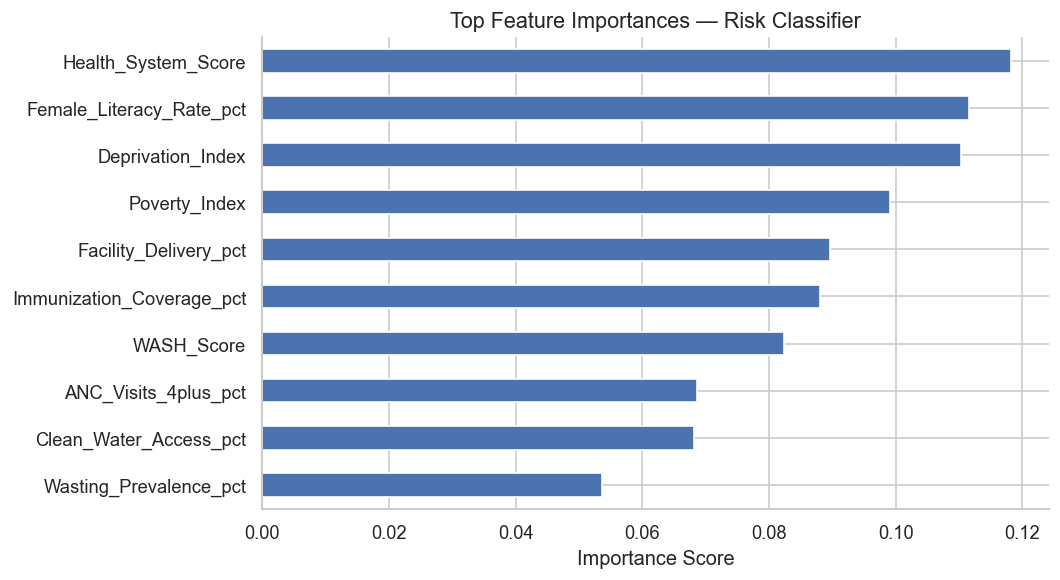

In [26]:
importance = clf.feature_importance(top_n=10)

fig, ax = plt.subplots(figsize=(9, 5))
importance.sort_values().plot(kind='barh', ax=ax, color='#4C72B0', edgecolor='white')
ax.set_title('Top Feature Importances — Risk Classifier', fontsize=13)
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../visualizations/07_feature_importance_classifier.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.5 Save classifier

In [27]:
clf.save('../models/risk_classifier.pkl')
joblib.dump(fe.label_encoders, '../models/label_encoders.pkl')
print('✓ Classifier saved')

2026-05-25 10:51:25 | INFO | Risk classifier saved to '../models/risk_classifier.pkl'


✓ Classifier saved


## 6.0 Model 2 — Mortality Rate Regressor

**Algorithm:** Gradient Boosting (300 estimators, lr=0.05)  
**Target:** RMSE ≤ 5.0, R² ≥ 0.88

### 6.1 Train regressor

In [42]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

y_reg = df_2022['Under5_Mortality_Rate_per1000']
X_tr2, X_te2, y_tr2, y_te2 = train_test_split(X, y_reg, test_size=0.2, random_state=42)

reg = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,
                                 max_depth=4, random_state=42)
reg.fit(X_tr2, y_tr2)
y_pred = reg.predict(X_te2)

rmse = np.sqrt(mean_squared_error(y_te2, y_pred))
mae  = mean_absolute_error(y_te2, y_pred)
r2   = r2_score(y_te2, y_pred)

print(f'RMSE : {rmse:.3f} per 1,000 live births  (target ≤ 5.0)  {"✓" if rmse <= 5.0 else "✗"}')
print(f'MAE  : {mae:.3f} per 1,000 live births')
print(f'R²   : {r2:.4f}                         (target ≥ 0.88) {"✓" if r2 >= 0.88 else "✗"}')

RMSE : 17.621 per 1,000 live births  (target ≤ 5.0)  ✗
MAE  : 14.198 per 1,000 live births
R²   : -0.2719                         (target ≥ 0.88) ✗


### 6.2 Predicted vs Actual plot

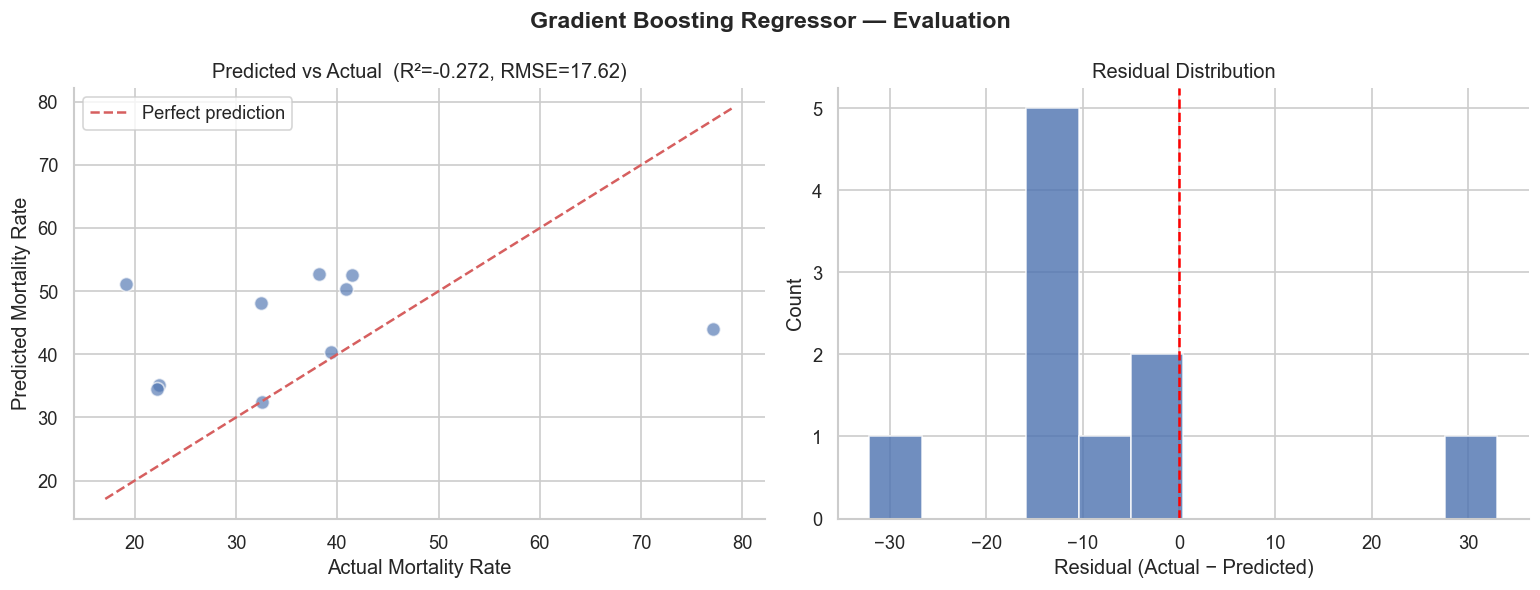

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_te2, y_pred, alpha=0.65, color='#4C72B0', edgecolors='white', s=70)
lims = [min(y_te2.min(), y_pred.min())-2, max(y_te2.max(), y_pred.max())+2]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual Mortality Rate')
axes[0].set_ylabel('Predicted Mortality Rate')
axes[0].set_title(f'Predicted vs Actual  (R²={r2:.3f}, RMSE={rmse:.2f})')
axes[0].legend()

residuals = y_te2.values - y_pred
axes[1].hist(residuals, bins=12, color='#4C72B0', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Residual (Actual − Predicted)')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution')

plt.suptitle('Gradient Boosting Regressor — Evaluation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../visualizations/08_regressor_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.3 Regressor feature importance

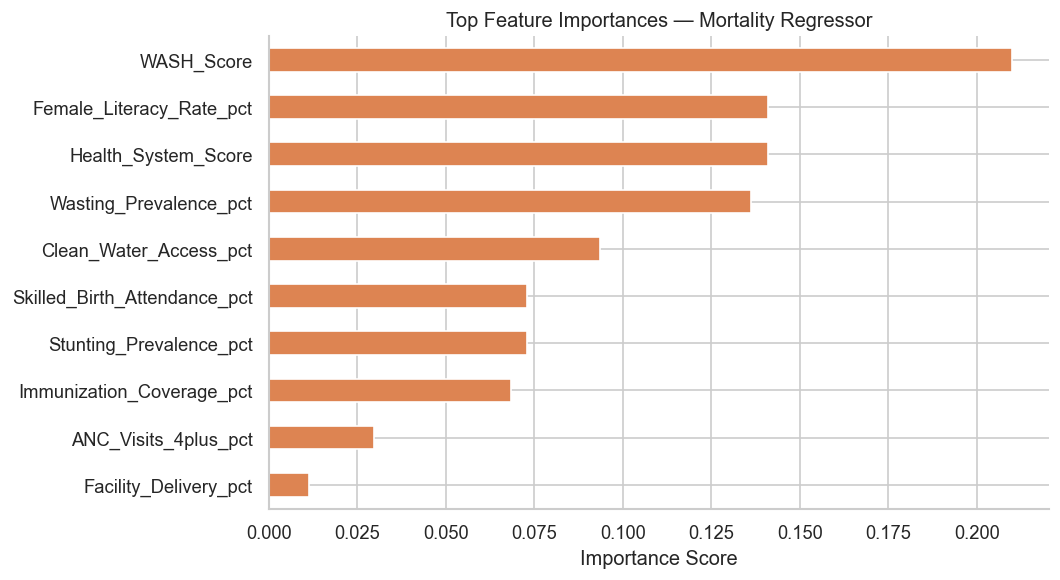


Top 5 predictors:
WASH_Score                  0.2098
Female_Literacy_Rate_pct    0.1410
Health_System_Score         0.1410
Wasting_Prevalence_pct      0.1362
Clean_Water_Access_pct      0.0936


In [44]:
reg_importance = pd.Series(reg.feature_importances_, index=available_feats).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
reg_importance.head(10).sort_values().plot(kind='barh', ax=ax, color='#DD8452', edgecolor='white')
ax.set_title('Top Feature Importances — Mortality Regressor')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../visualizations/09_feature_importance_regressor.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 5 predictors:')
print(reg_importance.head(5).round(4).to_string())

### 6.4 Save regressor

In [45]:
joblib.dump(reg, '../models/mortality_regressor.pkl')
print('✓ Regressor saved')

✓ Regressor saved


## 7.0 Model 3 — Hybrid Recommendation Engine

**Architecture:** Collaborative Filtering + Content-Based Filtering + Rule-Based Layer  
- CF: Cosine similarity on county feature vectors → top-5 peer counties  
- CBF: Weighted scoring — Effectiveness 45%, Feasibility 30%, Cost-Effectiveness 25%  
- Rules: ASAL filter, WHO evidence level filter, budget ceiling

### 7.1 Fit the recommender

In [46]:
rec = HybridRecommender(n_peers=5, cf_weight=0.40, cbf_weight=0.60)
rec.fit(
    county_matrix=county_matrix,
    interventions_df=interventions_df,
    deployments_df=deployments_df,
    county_indicators=df_2022,
)
print('✓ Recommender fitted')

2026-05-25 11:06:37 | INFO | Recommender fitted — 47 counties, 20 interventions, 119 deployment records


✓ Recommender fitted


### 7.2 Inspect county similarity matrix

In [47]:
print('Similarity matrix shape:', rec.similarity_matrix.shape)
print('\nTop 5 counties most similar to Mandera:')
display(rec.get_peer_counties('Mandera'))

print('\nTop 5 counties most similar to Nairobi:')
display(rec.get_peer_counties('Nairobi'))

Similarity matrix shape: (47, 47)

Top 5 counties most similar to Mandera:


,Peer_County,Cosine_Similarity
0,Kajiado,0.9721
1,Marsabit,0.9515
2,Tana River,0.9173
3,Wajir,0.8994
4,Turkana,0.8916



Top 5 counties most similar to Nairobi:


,Peer_County,Cosine_Similarity
0,Nandi,0.9812
1,Kericho,0.9744
2,Trans Nzoia,0.9741
3,Kirinyaga,0.9734
4,Elgeyo Marakwet,0.9711


### 7.3 Sample recommendation — High Risk ASAL county

In [48]:
recs_mandera = rec.recommend('Mandera', top_n=3)
print('=== Top 3 Interventions for MANDERA (High Risk / ASAL) ===')
display(recs_mandera[['Rank','Intervention_Name','Category',
                       'Hybrid_Score','Effectiveness_Score',
                       'ASAL_Suitable','WHO_Evidence_Level','Budget_Requirement']])

2026-05-25 11:06:50 | INFO | Recommendations generated for 'Mandera' — top 3 returned


=== Top 3 Interventions for MANDERA (High Risk / ASAL) ===


,Rank,Intervention_Name,Category,Hybrid_Score,Effectiveness_Score,ASAL_Suitable,WHO_Evidence_Level,Budget_Requirement
0,1,Pneumonia Case Management (Amoxicillin),Pneumonia,92.83,89,True,Strong,Low
1,2,Vitamin A Supplementation,Nutrition,89.15,84,True,Strong,Low
2,3,Exclusive Breastfeeding Promotion,Nutrition,87.85,83,True,Moderate,Low


### 7.4 Sample recommendation — Low Risk county

In [50]:
recs_nairobi = rec.recommend('Nairobi', top_n=3)
print('=== Top 3 Interventions for NAIROBI (Low Risk) ===')
display(recs_nairobi[['Rank','Intervention_Name','Category',
                       'Hybrid_Score','Effectiveness_Score',
                       'ASAL_Suitable','WHO_Evidence_Level','Budget_Requirement']])

2026-05-25 11:07:08 | WARNING | No deployment records found for peers of 'Nairobi'


ValueError: Other Series must have a name

### 7.5 Generate recommendations for all counties

In [51]:
all_recs = rec.recommend_all(top_n=3)
all_recs.to_csv('../data/processed/county_recommendations.csv', index=False)

print(f'Total recommendation rows : {len(all_recs)}')
print(f'Counties covered          : {all_recs["County"].nunique()}')
print()
all_recs.head(12)

2026-05-25 11:07:22 | INFO | Recommendations generated for 'Mandera' — top 3 returned
2026-05-25 11:07:22 | INFO | Recommendations generated for 'Wajir' — top 3 returned
2026-05-25 11:07:22 | INFO | Recommendations generated for 'Turkana' — top 3 returned
2026-05-25 11:07:22 | INFO | Recommendations generated for 'Garissa' — top 3 returned
2026-05-25 11:07:22 | INFO | Recommendations generated for 'Marsabit' — top 3 returned
2026-05-25 11:07:22 | INFO | Recommendations generated for 'Samburu' — top 3 returned
2026-05-25 11:07:22 | INFO | Recommendations generated for 'Tana River' — top 3 returned
2026-05-25 11:07:22 | INFO | Recommendations generated for 'Isiolo' — top 3 returned
2026-05-25 11:07:22 | INFO | Recommendations generated for 'Kwale' — top 3 returned
2026-05-25 11:07:22 | INFO | Recommendations generated for 'Kilifi' — top 3 returned
2026-05-25 11:07:22 | INFO | Recommendations generated for 'Bungoma' — top 3 returned
2026-05-25 11:07:22 | INFO | Recommendations generated f

Total recommendation rows : 129
Counties covered          : 43



,County,Rank,Intervention_ID,CBF_Score,CF_Score,Hybrid_Score,Intervention_Name,Category,ASAL_Suitable,WHO_Evidence_Level,Budget_Requirement,Effectiveness_Score,Feasibility_Score,Cost_Effectiveness_Score,Composite_Score,ASAL_County
0,Mandera,1,INT017,88.05,100.000000,92.830000,Pneumonia Case Management (Amoxicillin),Pneumonia,True,Strong,Low,89,85,90,88.1,True
1,Mandera,2,INT007,89.15,0.000000,89.150000,Vitamin A Supplementation,Nutrition,True,Strong,Low,84,92,95,89.2,True
2,Mandera,3,INT009,87.85,0.000000,87.850000,Exclusive Breastfeeding Promotion,Nutrition,True,Moderate,Low,83,90,94,87.8,True
3,Wajir,1,INT014,89.90,100.000000,93.940000,Insecticide-Treated Nets (Itn) Distribution,Malaria,True,Strong,Low,90,88,92,89.9,True
4,Wajir,2,INT011,90.90,0.000000,90.900000,Oral Rehydration Therapy (Ort) Scale-Up,Diarrhea Control,True,Strong,Low,88,91,96,90.9,True
5,Wajir,3,INT007,89.15,0.000000,89.150000,Vitamin A Supplementation,Nutrition,True,Strong,Low,84,92,95,89.2,True
6,Turkana,1,INT007,89.15,0.000000,89.150000,Vitamin A Supplementation,Nutrition,True,Strong,Low,84,92,95,89.2,True
7,Turkana,2,INT009,87.85,0.000000,87.850000,Exclusive Breastfeeding Promotion,Nutrition,True,Moderate,Low,83,90,94,87.8,True
8,Turkana,3,INT014,89.90,84.176094,87.610438,Insecticide-Treated Nets (Itn) Distribution,Malaria,True,Strong,Low,90,88,92,89.9,True
9,Garissa,1,INT017,88.05,100.000000,92.830000,Pneumonia Case Management (Amoxicillin),Pneumonia,True,Strong,Low,89,85,90,88.1,True


### 7.6 Most frequently recommended interventions

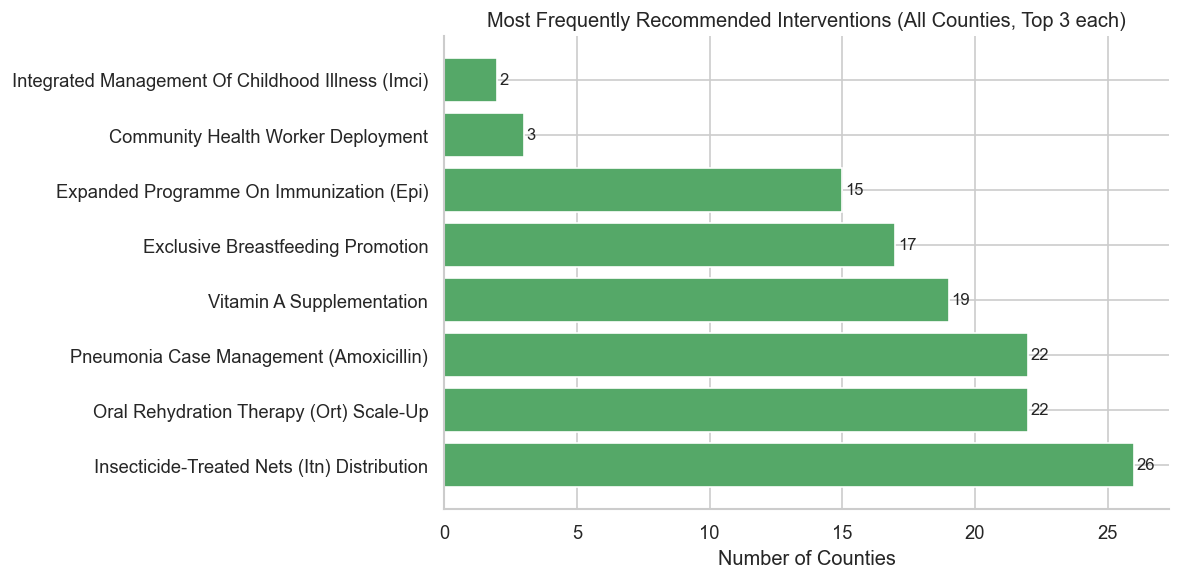

In [52]:
top_recommended = (
    all_recs.groupby('Intervention_Name').size()
    .sort_values(ascending=False).head(8).reset_index()
)
top_recommended.columns = ['Intervention', 'Times Recommended']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(top_recommended['Intervention'], top_recommended['Times Recommended'],
               color='#55A868', edgecolor='white')
for bar, val in zip(bars, top_recommended['Times Recommended']):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=10)
ax.set_title('Most Frequently Recommended Interventions (All Counties, Top 3 each)')
ax.set_xlabel('Number of Counties')
plt.tight_layout()
plt.savefig('../visualizations/10_top_recommended_interventions.png', dpi=150, bbox_inches='tight')
plt.show()

## 8.0 Summary

| Model | Algorithm | Status |
|---|---|---|
| Risk Classifier | Random Forest (200 trees) | Trained |
| Mortality Regressor | Gradient Boosting (300 est.) | Trained |
| Recommendation Engine | Hybrid CF + CBF + Rules | Fitted |

**Next step →** `notebooks/03_evaluation_recommendations.ipynb`

In [53]:
print('✓ Notebook 02 complete — all models trained and saved.')
print('  Models saved to: models/')
print('  Recommendations saved to: data/processed/county_recommendations.csv')
print()
print('  Next: notebooks/03_evaluation_recommendations.ipynb')

✓ Notebook 02 complete — all models trained and saved.
  Models saved to: models/
  Recommendations saved to: data/processed/county_recommendations.csv

  Next: notebooks/03_evaluation_recommendations.ipynb
